使用设备: cuda
成功加载本地数据，共 6627 张图片
类别数量: 4
类别名称: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']
训练集: 5301 张
验证集: 1326 张

=== 初始化 ResNet18 ===

=== 初始化 MobileNetV2 ===

ResNet18 总参数: 11,178,564, 可训练参数: 2,052
MobileNetV2 总参数: 2,228,996, 可训练参数: 5,124

ResNet18 fc层参数需要梯度: [True, True]
MobileNetV2 classifier[1]参数需要梯度: [True, True]

=== 训练 ResNet18 ===
ResNet18 Epoch [1/5] | Loss: 0.5575 | Val Acc: 91.40%
ResNet18 Epoch [2/5] | Loss: 0.2752 | Val Acc: 93.97%
ResNet18 Epoch [3/5] | Loss: 0.2167 | Val Acc: 93.67%
ResNet18 Epoch [4/5] | Loss: 0.1906 | Val Acc: 94.72%
ResNet18 Epoch [5/5] | Loss: 0.1696 | Val Acc: 94.87%

=== 训练 MobileNetV2 ===
MobileNetV2 Epoch [1/5] | Loss: 0.5734 | Val Acc: 92.46%
MobileNetV2 Epoch [2/5] | Loss: 0.2807 | Val Acc: 94.57%
MobileNetV2 Epoch [3/5] | Loss: 0.2141 | Val Acc: 95.48%
MobileNetV2 Epoch [4/5] | Loss: 0.1803 | Val Acc: 96.08%
MobileNetV2 Epoch [5/5] | Loss: 0.1662 | Val Acc: 96.00%


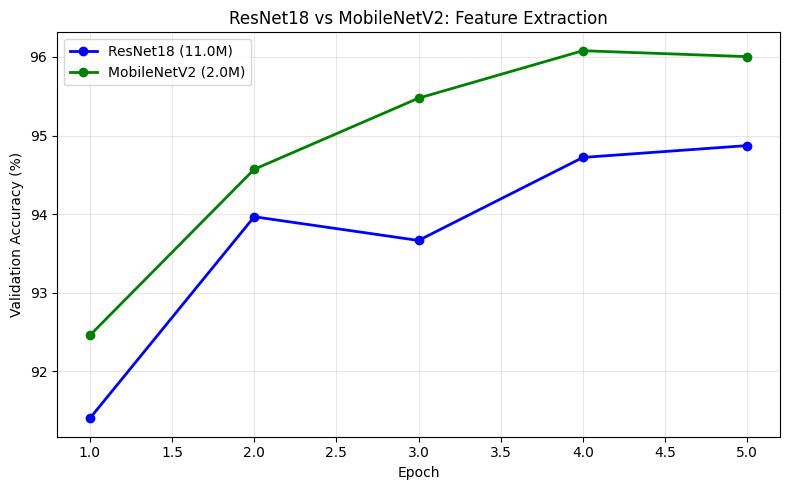


=== 结果总结 ===
ResNet18 最佳准确率: 94.87%
MobileNetV2 最佳准确率: 96.08%
参数数量对比: ResNet18 (11.0M) vs MobileNetV2 (2.0M)


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import os

# 设备配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# ── 数据加载和预处理 ──
# 数据预处理
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 预训练模型需要 224x224 输入
    transforms.RandomHorizontalFlip(),  # 随机水平翻转（数据增强）
    transforms.RandomRotation(15),  # 随机旋转 ±15 度
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 亮度/对比度变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet 统计的均值和
                        std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# 加载 PlantVillage 数据
data_dir = './data/PlantVillage'
try:
    full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
    print(f"成功加载本地数据，共 {len(full_dataset)} 张图片")
except FileNotFoundError:
    print("数据不存在，请确保数据目录 './data/PlantVillage' 存在")
    raise

# 查看类别
class_names = full_dataset.classes
print(f"类别数量: {len(class_names)}")
print(f"类别名称: {class_names}")

# 80% 训练，20% 验证
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# 验证集用 test_transform（不做数据增强）
val_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"训练集: {train_size} 张")
print(f"验证集: {val_size} 张")

# ── 1. 定义两个模型 ──
num_classes = len(class_names)  # 4

print("\n=== 初始化 ResNet18 ===")
# ResNet18 - 正确的顺序：先冻结，再替换最后一层
model_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# 先冻结所有参数
for param in model_resnet.parameters():
    param.requires_grad = False
# 然后替换最后一层
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, num_classes)
# 移动到设备
model_resnet = model_resnet.to(device)

print("\n=== 初始化 MobileNetV2 ===")
# MobileNetV2 - 同样的顺序
model_mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
# 先冻结所有参数
for param in model_mobilenet.parameters():
    param.requires_grad = False
# 然后替换最后一层
model_mobilenet.classifier[1] = nn.Linear(model_mobilenet.classifier[1].in_features, num_classes)
# 移动到设备
model_mobilenet = model_mobilenet.to(device)

# 检查参数
resnet_params = sum(p.numel() for p in model_resnet.parameters())
resnet_trainable = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
mobile_params = sum(p.numel() for p in model_mobilenet.parameters())
mobile_trainable = sum(p.numel() for p in model_mobilenet.parameters() if p.requires_grad)

print(f"\nResNet18 总参数: {resnet_params:,}, 可训练参数: {resnet_trainable:,}")
print(f"MobileNetV2 总参数: {mobile_params:,}, 可训练参数: {mobile_trainable:,}")

# 调试：检查哪些层需要梯度
print(f"\nResNet18 fc层参数需要梯度: {list(p.requires_grad for p in model_resnet.fc.parameters())}")
print(f"MobileNetV2 classifier[1]参数需要梯度: {list(p.requires_grad for p in model_mobilenet.classifier[1].parameters())}")

# ── 2. 训练 ResNet18 ──
criterion = nn.CrossEntropyLoss()
# 只优化需要梯度的参数
opt_resnet = optim.Adam(filter(lambda p: p.requires_grad, model_resnet.parameters()), lr=0.001)
resnet_val_accs = []

print("\n=== 训练 ResNet18 ===")
for epoch in range(5):
    # 训练
    model_resnet.train()
    train_loss = 0.0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # 前向传播
        outputs = model_resnet(images)
        loss = criterion(outputs, labels)
        
        # 反向传播和优化
        opt_resnet.zero_grad()
        loss.backward()
        opt_resnet.step()
        
        train_loss += loss.item()
    
    # 验证
    model_resnet.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            _, pred = outputs.max(1)
            correct += pred.eq(labels).sum().item()
            total += labels.size(0)
    
    acc = 100. * correct / total
    resnet_val_accs.append(acc)
    avg_loss = train_loss / len(train_loader)
    print(f"ResNet18 Epoch [{epoch+1}/5] | Loss: {avg_loss:.4f} | Val Acc: {acc:.2f}%")

# ── 3. 训练 MobileNetV2 ──
# 只优化需要梯度的参数
opt_mobile = optim.Adam(filter(lambda p: p.requires_grad, model_mobilenet.parameters()), lr=0.001)
mobile_val_accs = []

print("\n=== 训练 MobileNetV2 ===")
for epoch in range(5):
    # 训练
    model_mobilenet.train()
    train_loss = 0.0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # 前向传播
        outputs = model_mobilenet(images)
        loss = criterion(outputs, labels)
        
        # 反向传播和优化
        opt_mobile.zero_grad()
        loss.backward()
        opt_mobile.step()
        
        train_loss += loss.item()
    
    # 验证
    model_mobilenet.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_mobilenet(images)
            _, pred = outputs.max(1)
            correct += pred.eq(labels).sum().item()
            total += labels.size(0)
    
    acc = 100. * correct / total
    mobile_val_accs.append(acc)
    avg_loss = train_loss / len(train_loader)
    print(f"MobileNetV2 Epoch [{epoch+1}/5] | Loss: {avg_loss:.4f} | Val Acc: {acc:.2f}%")

# ── 4. 对比图 ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 6), resnet_val_accs, 'bo-', label=f'ResNet18 ({resnet_params//1000000:.1f}M)', linewidth=2)
ax.plot(range(1, 6), mobile_val_accs, 'go-', label=f'MobileNetV2 ({mobile_params//1000000:.1f}M)', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('ResNet18 vs MobileNetV2: Feature Extraction')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task_c_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== 结果总结 ===")
print(f"ResNet18 最佳准确率: {max(resnet_val_accs):.2f}%")
print(f"MobileNetV2 最佳准确率: {max(mobile_val_accs):.2f}%")
print(f"参数数量对比: ResNet18 ({resnet_params//1000000:.1f}M) vs MobileNetV2 ({mobile_params//1000000:.1f}M)")